In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Teen Phone Addiction: Model Training

This notebook performs two different tasks on the phone-addiction dataset:
1. Classification: Logistic Regression predicts whether a row is labeled Addicted or Not addicted.
2. Regression: Linear Regression predicts the numeric Addiction_Level score.

Scores of 8 or above are labeled Addicted. This is the threshold.

In [18]:
df = pd.read_csv("teen_phone_addiction_dataset.csv")
df = df.replace([" ", "NA", "N/A", ""], np.nan)
print("Dataset shape:", df.shape)
display(df.head())
print("\nMissing values by column:")
display(df.isna().sum())

Dataset shape: (3000, 25)


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6



Missing values by column:


ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

no missing values, dataset has: 3000 rows x 25 columns

### seperate features and targets
We will predict two targets in separate tasks. Addiction_Level and its derived Addiction_Status are both excluded from the features so neither task can use its answer as an input. Identifier columns are excluded because they identify records rather than describe useful behavior.

Keep only rows where both targets are available, so both tasks use the same rows.

In [19]:
# Create 0 = Not addicted and 1 = Addicted from the Addiction_Level score.
score = pd.to_numeric(df["Addiction_Level"], errors="coerce")

df["Addiction_Status"] = np.where(
    score.isna(),
    np.nan,
    (score >= 8).astype(int),
)

print(df[["Addiction_Level", "Addiction_Status"]].head())

   Addiction_Level  Addiction_Status
0             10.0               1.0
1             10.0               1.0
2              9.2               1.0
3              9.8               1.0
4              8.6               1.0


In [20]:
target_columns = ["Addiction_Level", "Addiction_Status"]
identifier_columns = ["ID", "Name", "Location"]
columns_to_drop = target_columns + identifier_columns

X = df.drop(columns=columns_to_drop, errors="ignore")
y_classification = df["Addiction_Status"]
y_regression = pd.to_numeric(df["Addiction_Level"], errors="coerce")

valid_rows = y_classification.notna() & y_regression.notna()
X = X.loc[valid_rows]
y_classification = y_classification.loc[valid_rows].astype(int)
y_regression = y_regression.loc[valid_rows]

print("Feature columns:", list(X.columns))
print("\nRows available for modeling:", len(X))

Feature columns: ['Age', 'Gender', 'School_Grade', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours']

Rows available for modeling: 3000


the target feature is the addiction level.
there are 80 different values of addiction levels ranging from 1 to 10.



### Create the classification target
Addiction_Level is a numeric score. We create a binary target from it: 0 means Not addicted (score below 8), and 1 means Addicted (score at least 8).

In [21]:
addiction_cutoff = 8

df["Addiction_Status"] = (
    df["Addiction_Level"] >= addiction_cutoff
).astype(int)

print("Target mapping: 0 = Not addicted; 1 = Addicted")
print(df["Addiction_Status"].value_counts().sort_index())

Target mapping: 0 = Not addicted; 1 = Addicted
Addiction_Status
0     707
1    2293
Name: count, dtype: int64


## USING TRAIN-TEST-SPLIT 
TRAINING:70-TESTING-30

In [22]:
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_classification,
    y_regression,
    test_size=0.30,
    random_state=42,
    stratify=y_classification,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 2100
Testing rows: 900


## preprocessing
numerical features are standardized and categorical features have been replaced eith most freequent values.

In [23]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessing, numeric_columns),
    ("categorical", categorical_preprocessing, categorical_columns),
])

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours']
Categorical columns: ['Gender', 'School_Grade', 'Phone_Usage_Purpose']


## classification function:
The function fits a classifier on the training set, predicts the test set, and prints accuracy, precision, recall, F1-score, and a confusion matrix. The confusion matrix rows are actual classes and columns are predicted classes.

In [24]:
def evaluate_classifier(model, model_name):
    model.fit(X_train, y_class_train)
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_class_test, predictions)
    labels = [0, 1]
    label_names = ["Not addicted", "Addicted"]

    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
    print("\nClassification report:")
    print(classification_report(
        y_class_test,
        predictions,
        labels=labels,
        target_names=label_names,
        zero_division=0,
    ))

    matrix = confusion_matrix(y_class_test, predictions, labels=labels)
    print("Confusion matrix (rows = actual, columns = predicted):")
    print(matrix)

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=label_names,
    ).plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return accuracy

## Logistic Regression function:
is designed for classification. Here it predicts the binary Addiction_Status target.

Logistic Regression is designed for classification. Here it predicts the binary Addiction_Status target.


Logistic Regression: Addiction Status
Accuracy: 0.9844 (98.44%)

Classification report:
              precision    recall  f1-score   support

Not addicted       0.96      0.97      0.97       212
    Addicted       0.99      0.99      0.99       688

    accuracy                           0.98       900
   macro avg       0.98      0.98      0.98       900
weighted avg       0.98      0.98      0.98       900

Confusion matrix (rows = actual, columns = predicted):
[[206   6]
 [  8 680]]


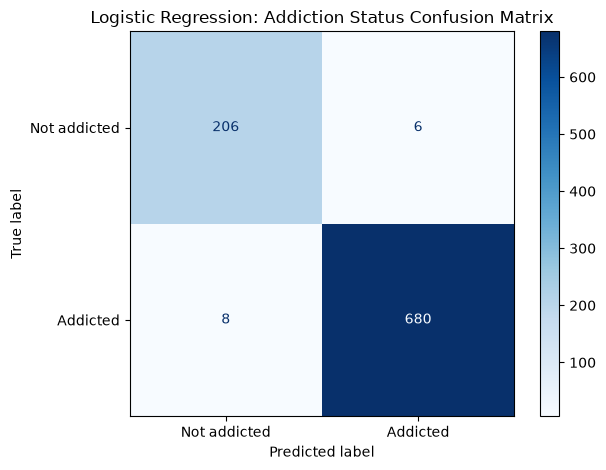

In [25]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

logistic_accuracy = evaluate_classifier(
    logistic_pipeline,
    "Logistic Regression: Addiction Status",
)

## Evaluation function for regression

Regression predicts a numeric score, so classification accuracy, a classification report, and a confusion matrix are not appropriate. We use:
- MAE: average absolute prediction error; lower is better.
- RMSE: gives larger errors more weight; lower is better.
- R²: how much variation the model explains; closer to 1 is generally better.

In [26]:
def evaluate_regressor(model, model_name):
    model.fit(X_train, y_reg_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_reg_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_reg_test, predictions))
    r_squared = r2_score(y_reg_test, predictions)

    print(f"\n{model_name}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r_squared:.4f}")

    return {"MAE": mae, "RMSE": rmse, "R2": r_squared}

Linear Regression predicts the numeric Addiction_Level score. We evaluate its predictions with MAE, RMSE, and R square.

In [27]:
linear_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression()),
])

regression_results = evaluate_regressor(
    linear_pipeline,
    "Linear Regression: Addiction Level",
)


Linear Regression: Addiction Level
Mean Absolute Error (MAE): 0.6676
Root Mean Squared Error (RMSE): 0.8183
R-squared (R²): 0.7314


# conclusion
Logistic Regression is evaluated on the binary Addicted/Not addicted task. 
Linear Regression is evaluated on the numeric Addiction_Level task. 

They predict different targets, so their scores should not be compared directly: classification accuracy is not the same kind of measure as regression MAE, RMSE, or R square.

In [28]:
import pickle
pickle.dump(logistic_pipeline, open("logistic_model.pkl", "wb"))

In [29]:
loaded_model = pickle.load(open("logistic_model.pkl", "rb"))